# 0. Libraries import

Functions from adsorption_calcs_utils are imported in this section. These functions are used to perform the materials selection, slabs generation and adsorption energies computation.

In [1]:
from adsorption_calcs_utils.cif_utils import get_material_and_cif
from adsorption_calcs_utils.run_calculations_utils import *

/home/edu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# 1. Material selection

In this section the materials database is filtered so as to select the best materials for generating slabs and computing adsorption energies. Crystals's data is taken from Materials Project and stored in `samples/materials_project_DB.csv`.

Materials are filtered by their composition. The `elements` parameter determines the chemical elements that must be in the filtered materials's composition, but doesn't indicate all the elements in their composition. The `composition` parameter indicates the number of different chemical symbols that must be in the filtered materials's chemical formula.

For example, if you select `elements = ["Ag", "Li"]` and `composition = 2`, all selected materials are alloys of Au and Li. On the other hand, iif you select `elements = ["Ag"]` and `composition = 2`, all selected materials are alloys of Au with one (and no more) chemical element.

The `e_above_hull` parameter controls the maximum energy above hull for the selected materials. Use this parameter to control de stability of the materials.

In [2]:
### Filtering materials
# Parameters
elements = ["Ag"]
composition = 1
e_above_hull = 0.1 # Default: 0.05

# Materials database
csv_file = "./samples/materials_project_DB.csv"

materials = get_material_and_cif(e_above_hull, composition=composition, elements=elements, verbose=True, csv_file=csv_file)

Index	Material	Material ID	Energy above hull	Number of sites in primitive cell
0	Ag        	mp-8566   	0.00000			4
1	Ag        	mp-124    	0.00213			1
2	Ag        	mp-10597  	0.00767			2
3	Ag        	mp-989737 	0.01038			3
4	Ag        	mp-2646971	0.03434			1

Number of materials: 5


In the following cell, you can choose one of the previous materials to be used for slabs generation and adsorption energies calculation.

Choose the material by its index in the previous output,

In [3]:
### Select material
index = 1

material, material_id, e_hull, nsites = select_material(materials, index)

Chosen material:
Ag, mp-124


# 2. Slabs generation

In this section, slabs are generated from the selected material. The material's crystal structure is stored in a `CIF` file in `samples/cif`. The generated slabs are stored in `results/slabs` as `joblib` files.

The `min_slab` parameters indicates the minimum slab's height in Ångström (Å). This parameter should be chosen so as to ensure enough number of layers. In this work, six layers are used for each slab.

`if_exists_do` controls what to do if you're trying to create an slab that already exists. It's useful when you're not satisfied with the resulting slab and want to try a new `min_slab` value. Options are:
    - `"nothing"`: Don't do nothing and skip the slab creation.
    - `"replace"`: Replace the existing slab.
    - Any other option is treated as `"nothing"`.

In [4]:
### Create slab objects for the selected material

# Parameters for slabs creation.
min_slab = 20.0
if_exists_do = "nothing"

# Create slabs and save them in .joblib files
storing_path = "./results/slabs"
cif_path='./samples/cif/'
create_slabs_per_miller_index(material, material_id, min_slab=min_slab, if_exists_do=if_exists_do, path=storing_path, cif_path=cif_path)

Ag
(1, 0, 0):	The slab already exists.	Number of atoms: 10,	Number of layers: 10
(1, 1, 0):	The slab already exists.	Number of atoms: 14,	Number of layers: 14
(1, 1, 1):	The slab already exists.	Number of atoms: 9,	Number of layers: 9


# 3. Slabs .in files generation

In this section, the slabs `.in` files for `QE` relax computations are generated.

`replace_in` parameter is used to re-write these files. IF set to `True`, the `.in` files already existing will be replaced by the new ones, if they share name. The files are stored in `results/ads_calc_results/[material_pretty_formula]_mp-[mp_identifier]`.

In `results` there is a `CSV` file called `calcs_history.csv` which save the record of the computations of adsorption energies over all surfaces. The data saved for each surface includes Material's pretty formula, material's MP Id, energy above hull, Miller index, number of layers, number of sites in the supercell, slab height, supercell parameters and whether the surface is stepped.

Each supercell is shown by `ASE` before its `.in` file is created. The user must indicate if the surface is stepped or not. For this cell properly works, it must be run in Jupyter Notebook or lab.

In [5]:
### Slabs .in files creation
# Parameters
replace_in = False


# ¡Ojo acá! Para arreglar en el código. La carta 'outdir' está deprecada, se debe usar la variable de entorno
# ESPRESSO_TMPDIR
folder_path = 'results/ads_calc_results'
pseudo_dir = './samples/pseudos'
calcs_record_csv_path = './results/calcs_history.csv'
slabs_path = './results/slabs'
model_path = './model.in'
potentials_csv_file = './samples/potentials.csv'
cleaned_in_files_creation(material, material_id, e_hull, folder_path, replace_in=replace_in, pseudo_dir=pseudo_dir,
                          csv_path=calcs_record_csv_path, slabs_path=slabs_path, model_path=model_path, csv_file=potentials_csv_file)

Ag_mp-124
100
	The .in file was already created for this surface. See the calculations record csv.
110
	The .in file was already created for this surface. See the calculations record csv.
111
	The .in file was already created for this surface. See the calculations record csv.


After `.in` file creation, `QE` calculations must be performed. The resulting `.out` files must be saved in the same folder that contains the `.in` files recently created. 

# 4.Update calculation record and create slab+adsorbate .in files

In this section, the calculations record `CSV` file is updated with the results of the `QE` DFT relax computations of the slabs.Then, the `.in` files of the slab+adsorbate systems are created. These files are saved in the same folder as the slabs `.in` files.

Total and for each type count of adsorption sites are shown for each material's surface. Also, These adsorption sites are plotted.

Ag_mp-124

-----
100
-----
Number of sites:
	bridge: 2
	hollow: 0
	ontop:  1

Total sites: 3


/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:451: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([coord[0]], [coord[1]], label=f"{site} {k}", s=100, marker=markers[site], c=colors[k])
/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:462: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(cell_vertices[:, 0], cell_vertices[:, 1], 'b-', linewidth=2, linestyle='--', c='grey', label="Primitive cell´s boundary") # Draw primitive cell´s border
/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:462: UserWarn

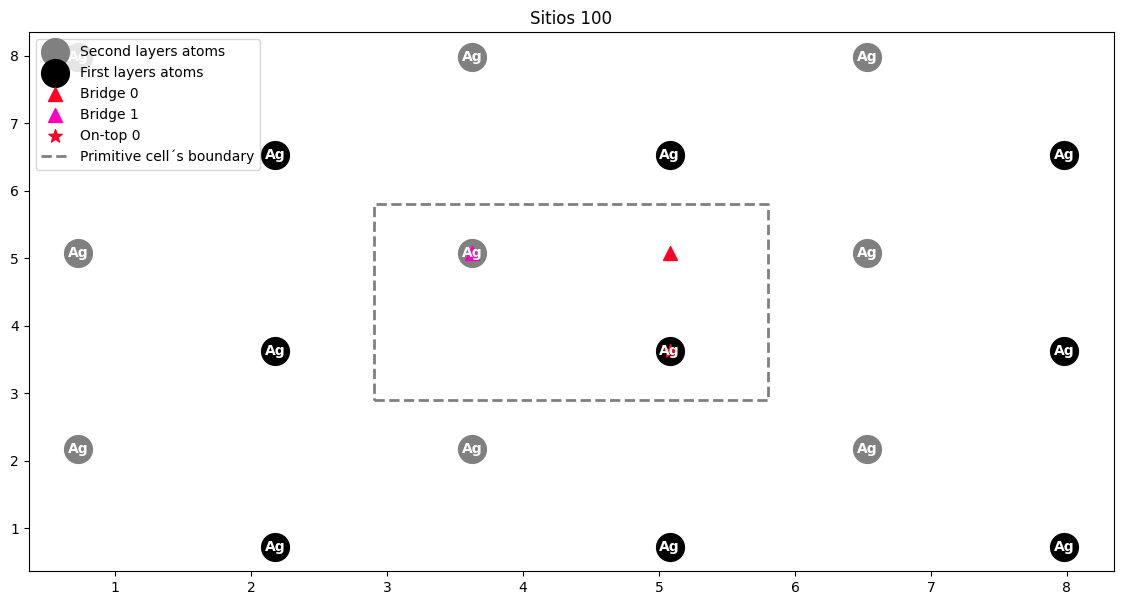



-----
110
-----
Number of sites:
	bridge: 3
	hollow: 0
	ontop:  1

Total sites: 4


/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:451: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([coord[0]], [coord[1]], label=f"{site} {k}", s=100, marker=markers[site], c=colors[k])
/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:462: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(cell_vertices[:, 0], cell_vertices[:, 1], 'b-', linewidth=2, linestyle='--', c='grey', label="Primitive cell´s boundary") # Draw primitive cell´s border
/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:462: UserWarn

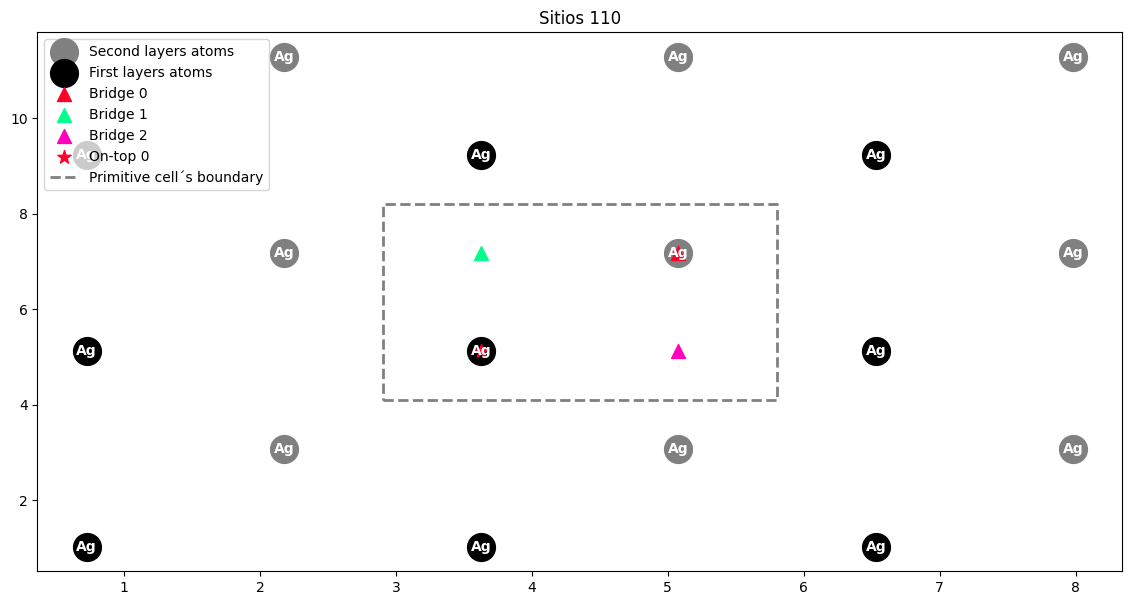



-----
111
-----
Number of sites:
	bridge: 2
	hollow: 2
	ontop:  1

Total sites: 5


/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:451: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter([coord[0]], [coord[1]], label=f"{site} {k}", s=100, marker=markers[site], c=colors[k])
/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:462: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "b-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(cell_vertices[:, 0], cell_vertices[:, 1], 'b-', linewidth=2, linestyle='--', c='grey', label="Primitive cell´s boundary") # Draw primitive cell´s border
/home/edu/repos/Li_Adsorption_ML/adsorption_calcs_utils/run_helpers.py:462: UserWarn

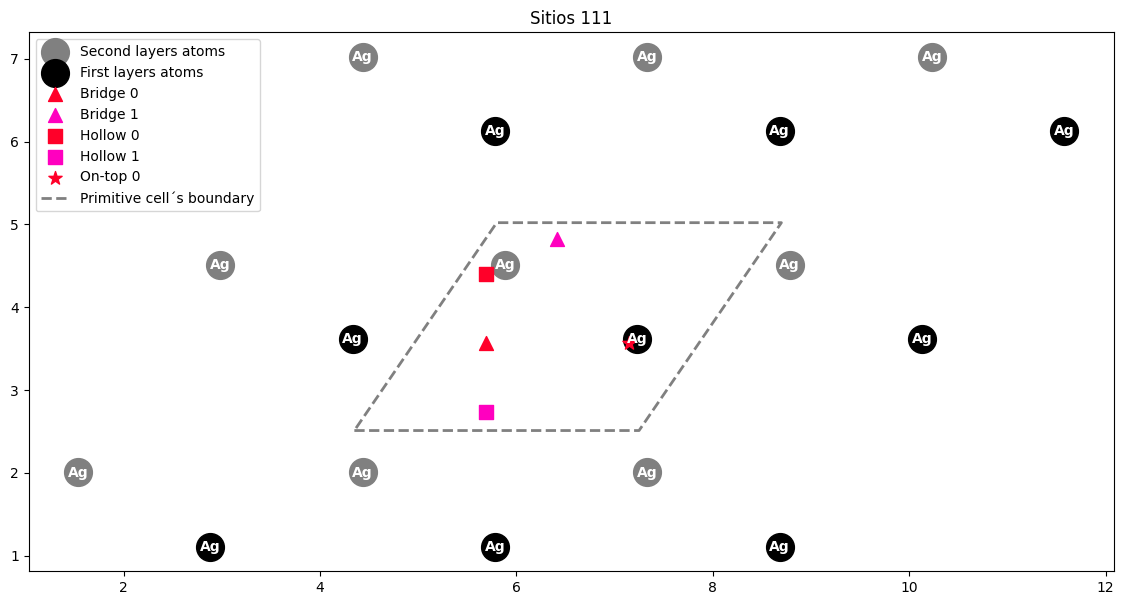

In [6]:
ads_in_files_creation(material, material_id, folder_path, csv_path=calcs_record_csv_path,
                      potentials_csv_file=potentials_csv_file)

# 5. Update calculations record CSV file and adsorption energies CSV file.

In this section the calculations record `CSV` file is updated with the last calculations corresponding to the selected material. Also, the adsorption energies are uploaded to the adsorption energies database CSV file, which can be found in this repository as `results/ads_energies_db.csv`.

`if_energies_are_in_base_do` parameter controls what to do if there are rows in adsorption energies database of the given material. Options:
                - `"nothing"`: Don´t do anything. A warning message is printed.
                - `"replace"`: Remove all material´s rows and add the new rows got from the .out files.

In [10]:
# Parameters
if_energies_are_in_base_do = 'nothing'

energies_csv = 'results/ads_energies_db.csv'
complete_history_with_ads_calcs(folder_path, material, material_id, csv_path=calcs_record_csv_path)
update_energy_adsorption_database(material, material_id, folder_path, if_energies_are_in_base_do=if_energies_are_in_base_do,
                                 energies_csv=energies_csv)

The adsorption energies of the given material´s surfaces where already loaded in adsorption energies database.


# 6. Show number of adsorption energies succesfully computed by adsorption site type and chemical system

In this section, you can consult the number of adsorption energies saved in `ads_energies_db.csv` file by adsorption site types and chemical system. 
Impresión de cantidad de sitios de adsorpción calculados por combinación de elementos químicos

`elements` is an optional parameter that allows you to filter the chemical system by its defining chemical elements. If you want to see all the chemical systems, set it as `None`. Otherwise, set it as a `list` of `str`, where each string corresponds to a chemical symbol.

In [6]:
# Parameters
elements = ['Ag'] # default: None

energies_csv = 'results/ads_energies_db.csv'
pd.set_option("display.max_rows", None) # To show all rows
adsorption_energies_count(energies_csv=energies_csv, elements=elements)

site type            bridge  hollow  ontop
element_combination                       
(Ag,)                     9       9      7
(Ag, Li)                  5       2      5


Total cases calculated (surface+adsorption site): 37
Number of chemical systems tried: 2


# Consultar base de datos de historial

In [12]:
mat_summary = consult_history_db('Ag')
pd.set_option('display.max_columns', None)
display(mat_summary)

,material,material-id,e_hull,indice_de_miller,capas,nsites,altura_slab,a,b,c,alpha,beta,gamma,escalonada,exito_limpia,sitios_bridge,sitios_hollow,sitios_ontop,sitios_totales,bridge_enviados,hollow_enviados,ontop_enviados,bridge_exitosos,hollow_exitosos,ontop_exitosos,prob_convergencia,prob_tiempo,errores
225,Ag,mp-8566,0.000000,100,6,16,9.244084,2.911131,9.463709,29.244084,90.000000,90.000000,90.000000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
226,Ag,mp-8566,0.000000,110,6,24,7.598590,5.042228,9.463709,27.598590,90.000000,94.715004,90.000000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
227,Ag,mp-8566,0.000000,111,6,21,7.598590,5.042228,9.901337,27.598590,99.638976,94.715004,75.248718,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0
228,Ag,mp-124,0.002127,100,6,6,10.260891,2.902218,2.902218,30.260891,90.000000,90.000000,90.000000,False,True,2.0,0.0,1.0,3.0,2.0,0.0,1.0,2.0,0.0,1.0,0,0,0
229,Ag,mp-124,0.002127,110,6,6,7.255546,2.902218,4.104356,27.255546,90.000000,90.000000,90.000000,False,True,3.0,0.0,1.0,4.0,2.0,0.0,1.0,2.0,0.0,1.0,0,0,0
230,Ag,mp-124,0.002127,111,6,6,11.917695,2.902218,2.902218,31.917695,87.496225,87.496225,60.000000,False,True,2.0,2.0,1.0,5.0,2.0,2.0,1.0,2.0,2.0,1.0,0,0,0
231,Ag,mp-10597,0.007669,100,6,12,13.497522,2.922299,4.701662,33.497522,90.000000,90.000000,90.000000,False,True,3.0,2.0,2.0,7.0,0.0,2.0,0.0,0.0,2.0,0.0,0,0,0
232,Ag,mp-10597,0.007669,110,6,12,7.489054,4.701662,5.061571,27.489054,94.715004,90.000000,90.000000,False,True,4.0,2.0,2.0,8.0,0.0,2.0,0.0,0.0,2.0,0.0,0,0,0
233,Ag,mp-10597,0.007669,111,6,12,7.583841,5.061571,5.535834,27.583841,92.260041,94.508939,62.795728,False,True,6.0,2.0,2.0,10.0,0.0,2.0,0.0,0.0,2.0,0.0,0,0,0
234,Ag,mp-989737,0.010382,100,6,18,4.252321,2.946094,21.613950,24.252321,90.000000,90.000000,90.000000,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0


In [13]:
consult_energies_database(material, material_id)

,material,material id,miller index,site type,site number,Adsorption energy
